### Hyper Parameters of DBSCAN:

There are Two Main Hyper Parameters that we are concerned with:

    - eps : The maximum distance between two samples for one to be considered as in the neighborhood of the other. This is not a maximum bound on the distances of points within a cluster. This is the most important DBSCAN parameter to choose appropriately for your data set and distance function. (Default is eps = 0.5)
    
    - *min_samples* : The number of samples (or total weight) in a neighborhood for a point to be considered as a core point. This includes the point itself. (Default is min_samples = 5)

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN

#### 2) Loading and Visualizing Data:

In [2]:
blobs_1 = pd.read_csv('cluster_two_blobs.csv')
blobs_2 = pd.read_csv('cluster_two_blobs_outliers.csv')

##### 1) Blobs:

In [3]:
blobs_1.head()

,X1,X2
0,0.046733,1.765120
1,-8.994134,-6.508186
2,0.650539,1.264533
3,-9.501554,-6.736493
4,0.057050,0.188215


In [4]:
blobs_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1000 non-null   float64
 1   X2      1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [5]:
blobs_1.describe()

,X1,X2
count,1000.000000,1000.000000
mean,-4.520520,-2.573348
std,4.917359,4.007334
min,-10.994381,-8.529507
25%,-9.443122,-6.535837
50%,-4.170365,-2.534595
75%,0.377097,1.395594
max,1.772096,2.932075


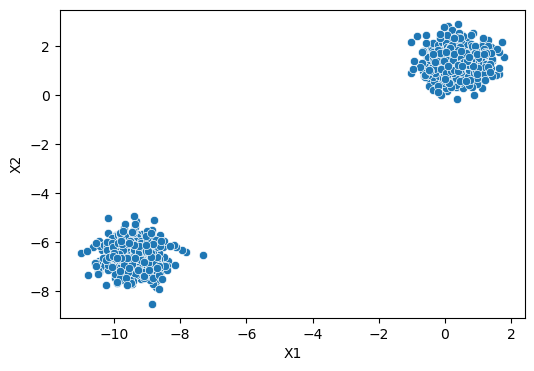

In [6]:
plt.figure(figsize= (6,4))
sns.scatterplot(data= blobs_1, x= 'X1', y= 'X2')
plt.show()

##### 2) Blobs with Outliers:

In [7]:
blobs_2.head()

,X1,X2
0,0.046733,1.765120
1,-8.994134,-6.508186
2,0.650539,1.264533
3,-9.501554,-6.736493
4,0.057050,0.188215


In [9]:
blobs_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1003 non-null   float64
 1   X2      1003 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [10]:
blobs_2.describe()

,X1,X2
count,1003.000000,1003.000000
mean,-4.518963,-2.575621
std,4.913326,4.005867
min,-10.994381,-8.529507
25%,-9.441817,-6.536523
50%,-4.000000,-2.000000
75%,0.375555,1.392050
max,1.772096,2.932075


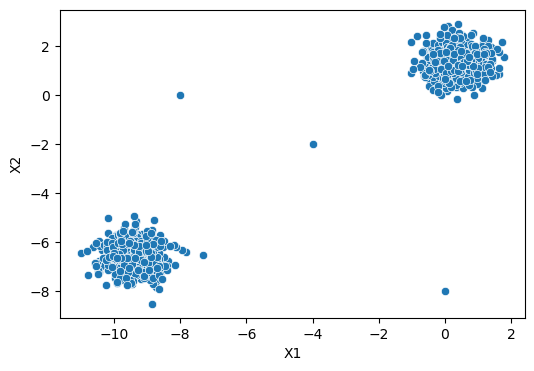

In [11]:
plt.figure(figsize= (6,4))
sns.scatterplot(data= blobs_2, x= 'X1', y= 'X2')
plt.show()

#### 3) Function to Visualize Clusters:

In [12]:
def visualize_clusters(model, data):
    '''
    Function to visualize Clusters on 2D data (data with 2 features)
    Parameters:
    model: Clustering Model Instance.
    data: 2D Data on which to fit Clustering Model.
    '''

    clusters = model.fit_predict(data)
    plt.figure(figsize= (6,4), dpi= 150)
    sns.scatterplot(data= data, x= "X1", y="X2", hue= clusters, palette= "dark")
    plt.show()

#### 4) Trying and Visualizing DBSCAN on both Datasets with Hyper Parameter Adjustment:

##### 1) DBSCAN with Default Parameters:

In [13]:
dbscan = DBSCAN()

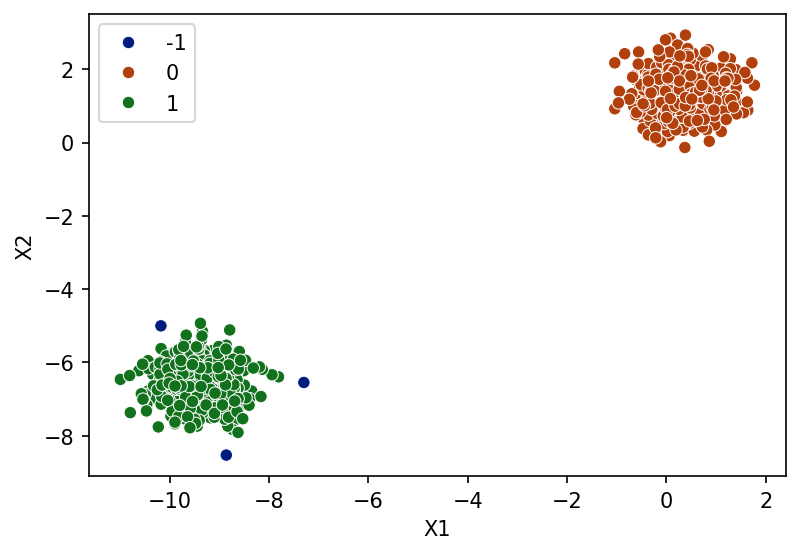

In [14]:
# Blobs:
visualize_clusters(dbscan, blobs_1)

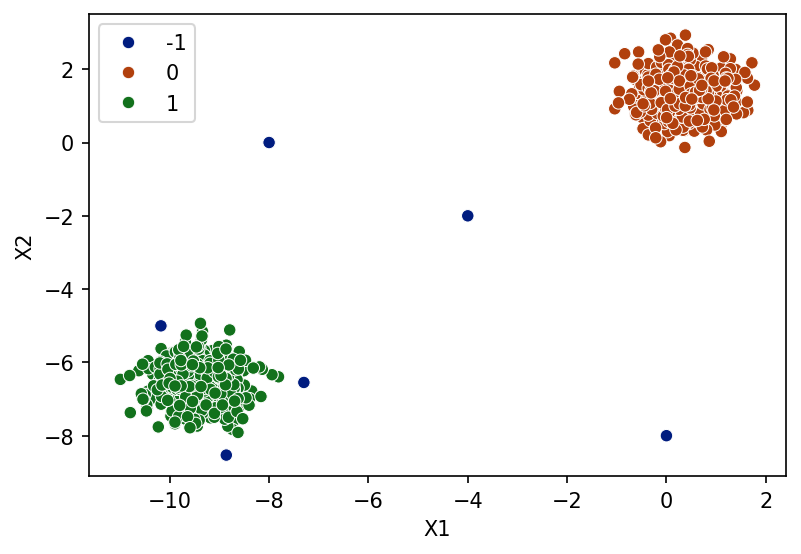

In [15]:
# Blobs with Outliers:
visualize_clusters(dbscan, blobs_2)

##### 2) Tiny Epsilon --> Tiny Max Distance --> Everything is an outlier (class=-1):

In [16]:
dbscan = DBSCAN(eps= 0.001)

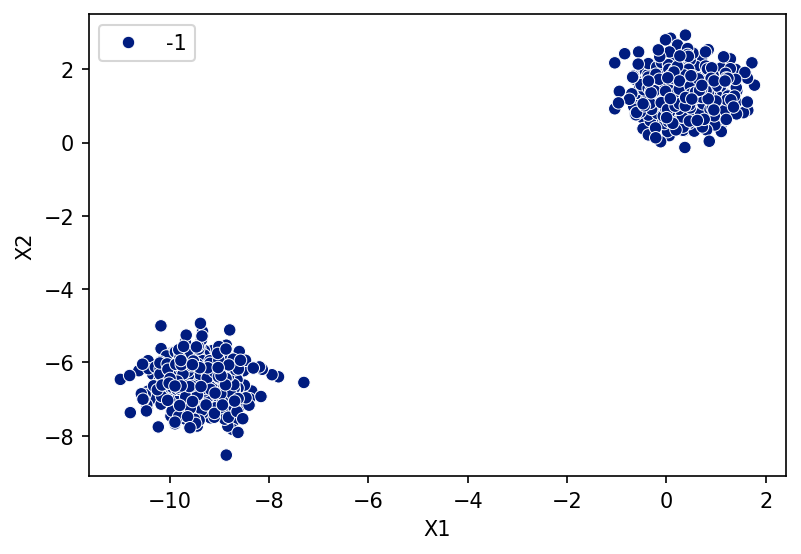

In [17]:
# Blobs:
visualize_clusters(dbscan, blobs_1)

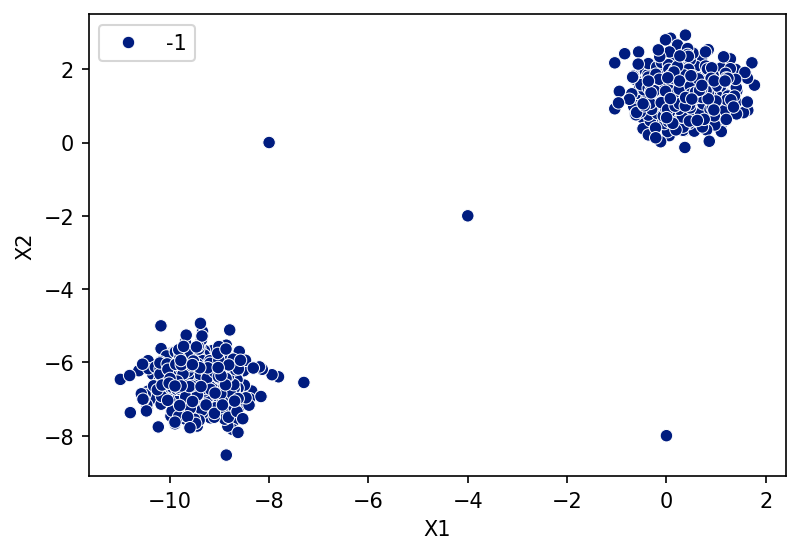

In [18]:
# Blobs with Outliers:
visualize_clusters(dbscan, blobs_2)

##### 3) Huge Epsilon --> Huge Max Distance --> Everything is in the same cluster (class=0):

In [19]:
dbscan = DBSCAN(eps= 10)

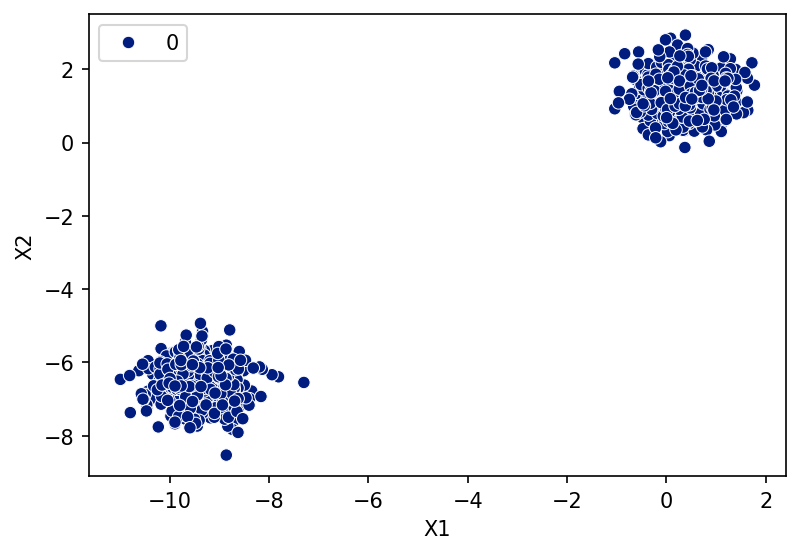

In [20]:
# Blobs:
visualize_clusters(dbscan, blobs_1)

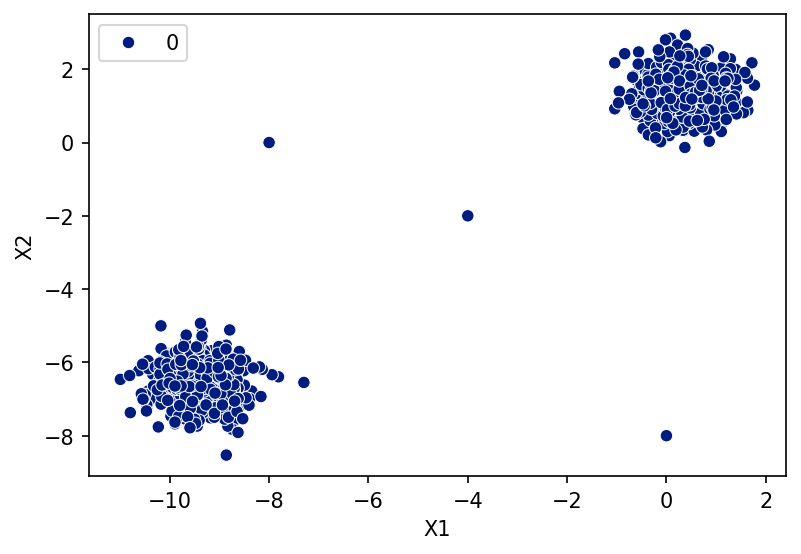

In [21]:
# Blobs with Outliers:
visualize_clusters(dbscan, blobs_2)

##### 4) Finding Good Epsilon Value::

- We will use Blobs with Outliers.

- As we can see clearly, Blobs with Outliers Should have 2 clusters and 3 points in between should be Outliers.

- So, we will find an Epsilon value which gives us Desired Result.

- Using That, we will find a General Method to Decide Epsilon value for all Datasets.

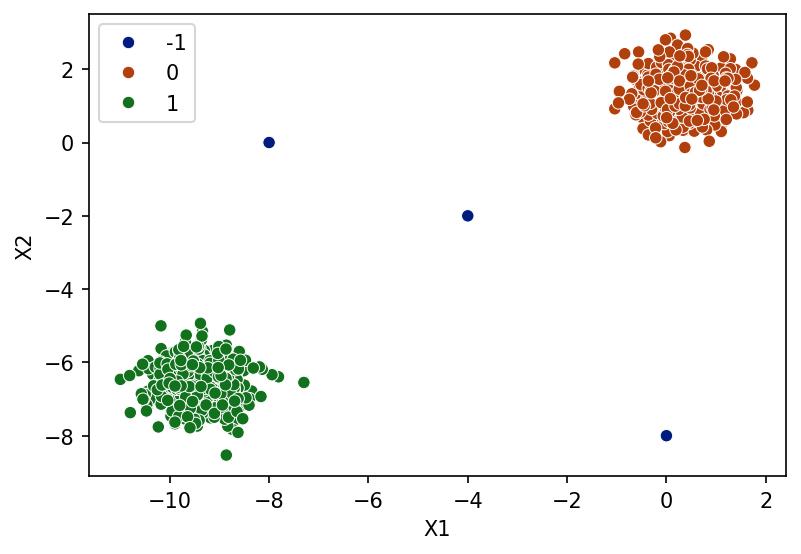

In [22]:
dbscan = DBSCAN(eps= 0.75)
visualize_clusters(dbscan, blobs_2)

Epsilon value of 0.75 works fine here.

In [23]:
dbscan.labels_

array([ 0,  1,  0, ..., -1, -1, -1], shape=(1003,))

In [24]:
# Finding How Many Points are Considered as Outliers:

dbscan.labels_ == -1 # -1 Label Denotes Outlier.

array([False, False, False, ...,  True,  True,  True], shape=(1003,))

In [26]:
np.sum(dbscan.labels_ == -1) # Number of Outlier points.

np.int64(3)

In [27]:
# Finding How Many Percentage of Points are Considered Outliers:

np.sum(dbscan.labels_ == -1) / len(dbscan.labels_) * 100 # percentage of Outlier Points.

np.float64(0.29910269192422734)

Now, we can run a loop for different "eps" values and see how many points OR what Percentage of Points are considered
Outliers for that Epsilon Value.

Using that, we can decide proper value of "eps".

In [29]:
num_of_outliers = []
percentage_of_outliers = []

for e in np.linspace(0.001, 10, 100):
    
    dbscan = DBSCAN(eps= e)
    
    dbscan.fit(blobs_2)
    
    # Number of Outlier points
    num_of_outliers.append(np.sum(dbscan.labels_ == -1))
    
    # percentage of Outlier Points
    percentage_of_outliers.append(np.sum(dbscan.labels_ == -1) / len(dbscan.labels_) * 100)

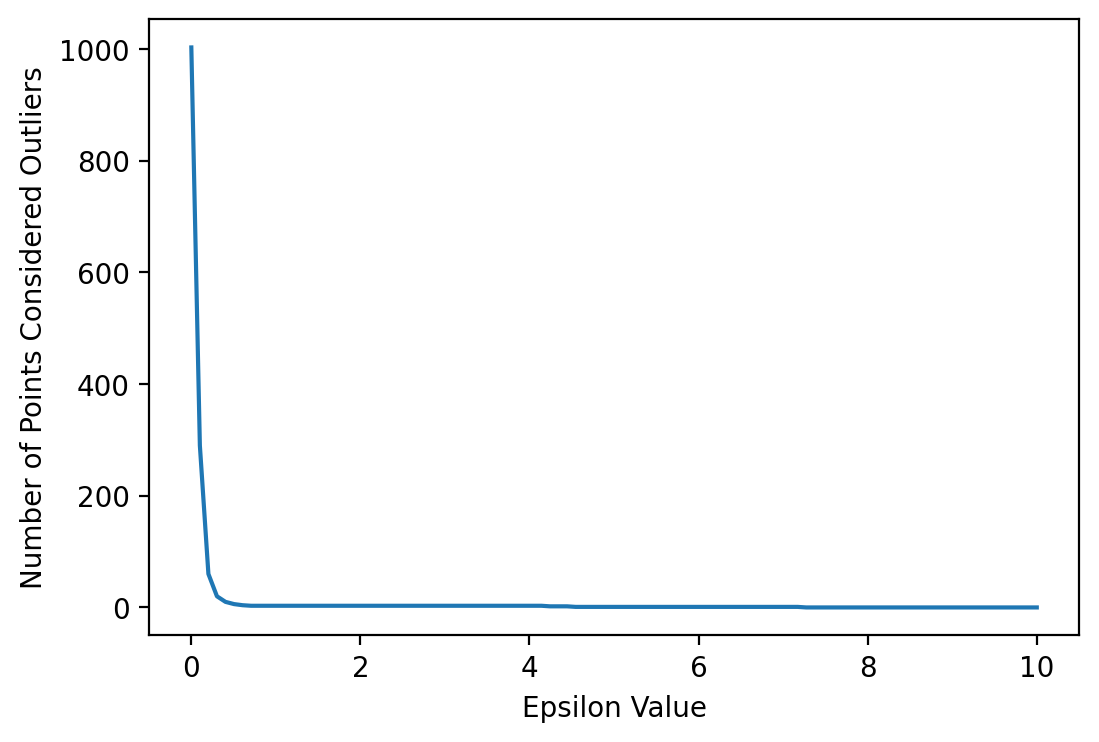

In [31]:
# Plotting Number of Outliers:

plt.figure(figsize= (6,4), dpi=200)
plt.plot(np.linspace(0.001, 10, 100), num_of_outliers)
plt.xlabel('Epsilon Value')
plt.ylabel('Number of Points Considered Outliers')
plt.show()

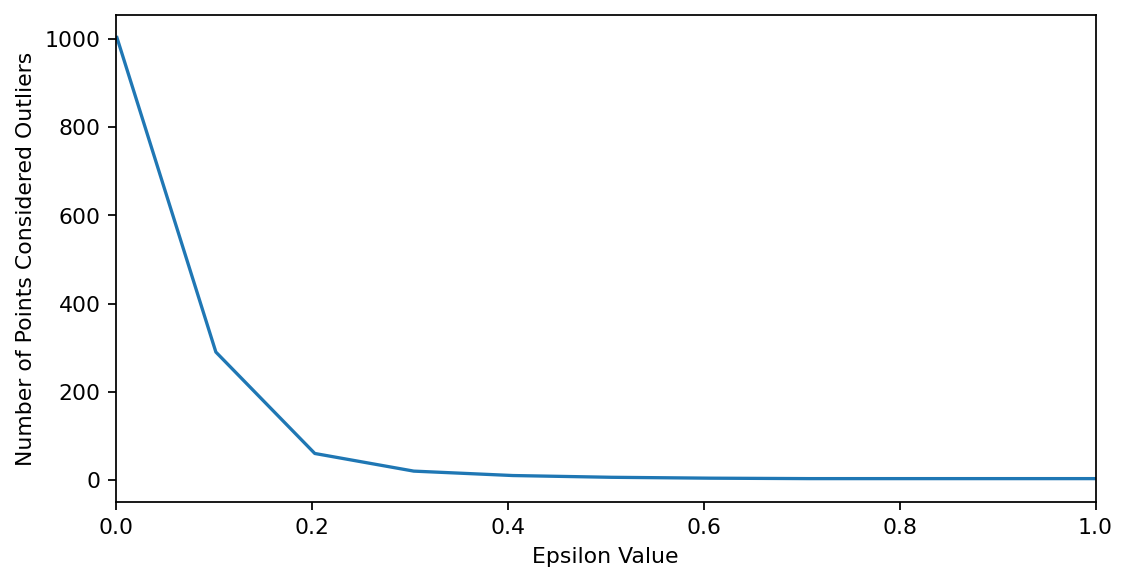

In [32]:
# We can cut x-limit to zoom in on Graph:

plt.figure(figsize= (8,4), dpi= 158)
plt.plot(np.linspace(0.001, 10, 100), num_of_outliers)
plt.xlabel('Epsilon Value')
plt.ylabel('Number of Points Considered Outliers')
plt.xlim(0,1)
plt.show()

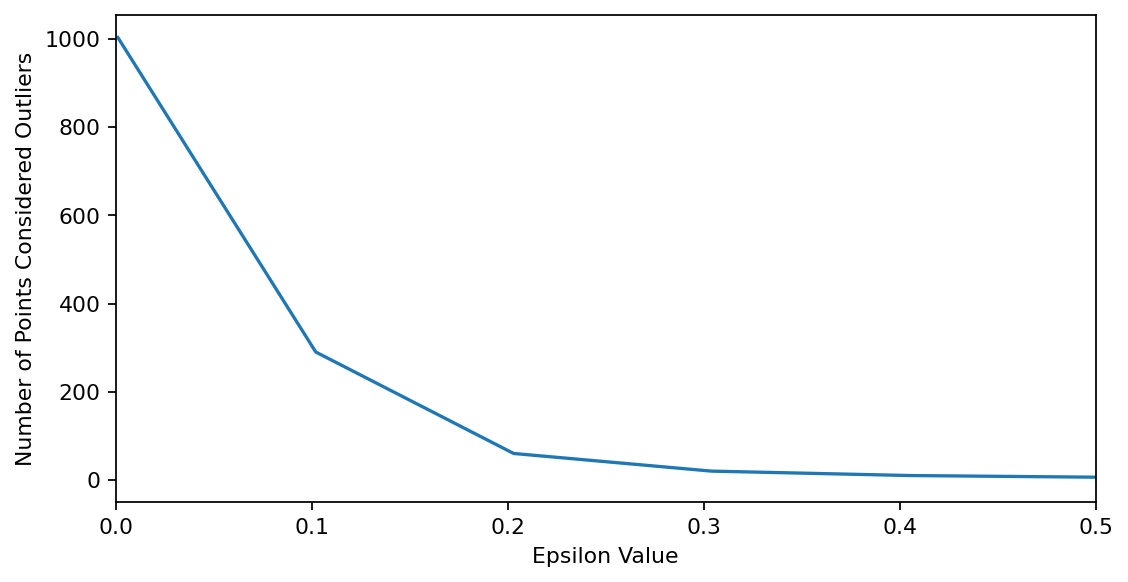

In [33]:
# We can cut x-limit to zoom in on Graph:

plt.figure(figsize= (8,4), dpi= 158)
plt.plot(np.linspace(0.001, 10, 100), num_of_outliers)
plt.xlabel('Epsilon Value')
plt.ylabel('Number of Points Considered Outliers')
plt.xlim(0,0.5)
plt.show()

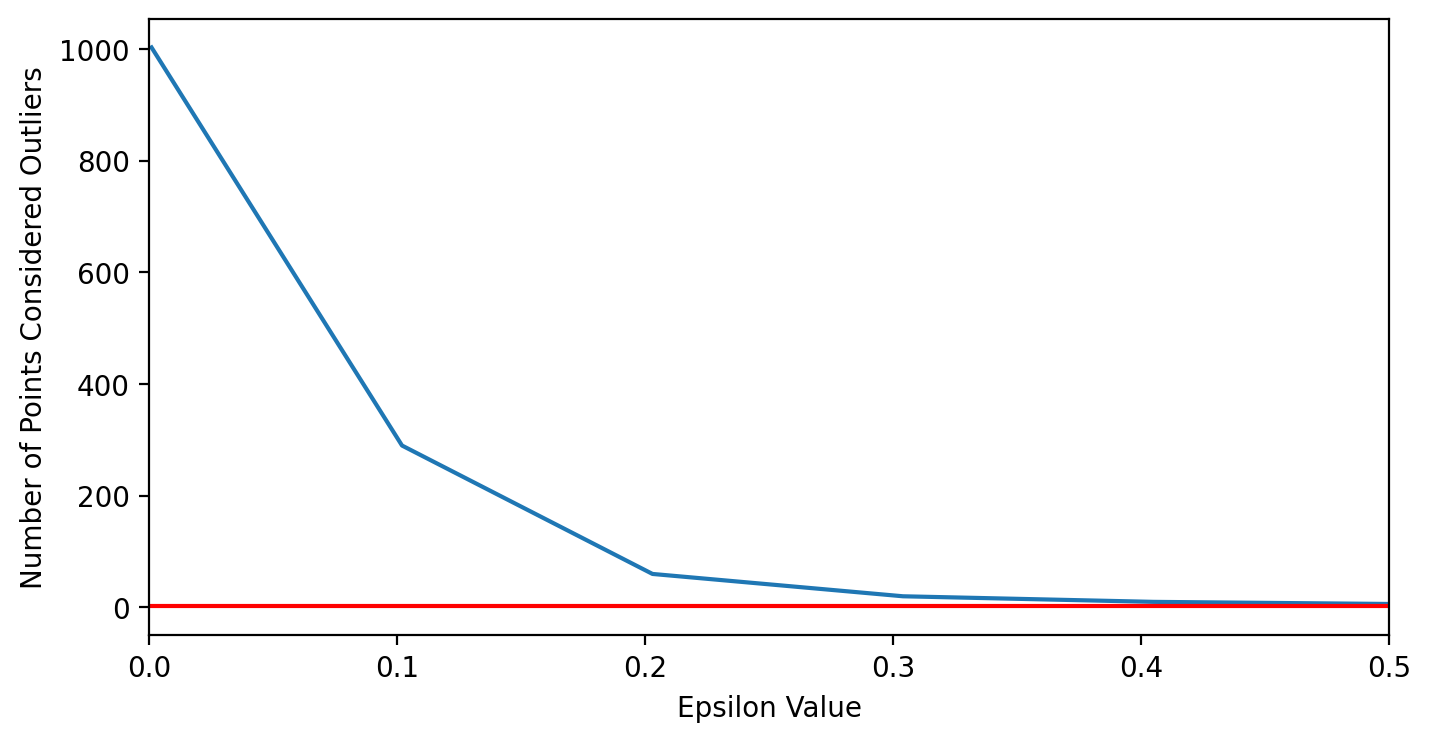

In [34]:
# We can Draw Line on Y-Axis for Y=3, to see exactly which value of epsilon is proper.

plt.figure(figsize= (8,4), dpi=200)
plt.plot(np.linspace(0.001, 10, 100), num_of_outliers)
plt.xlabel('Epsilon Value')
plt.ylabel('Number of Points Considered Outliers')
plt.xlim(0,0.5)
plt.hlines(y=3, xmin=0, xmax=1, color= 'red')
plt.show()

Epsilon Value of 0.4 or 0.5 Seems to give us Desired Result.

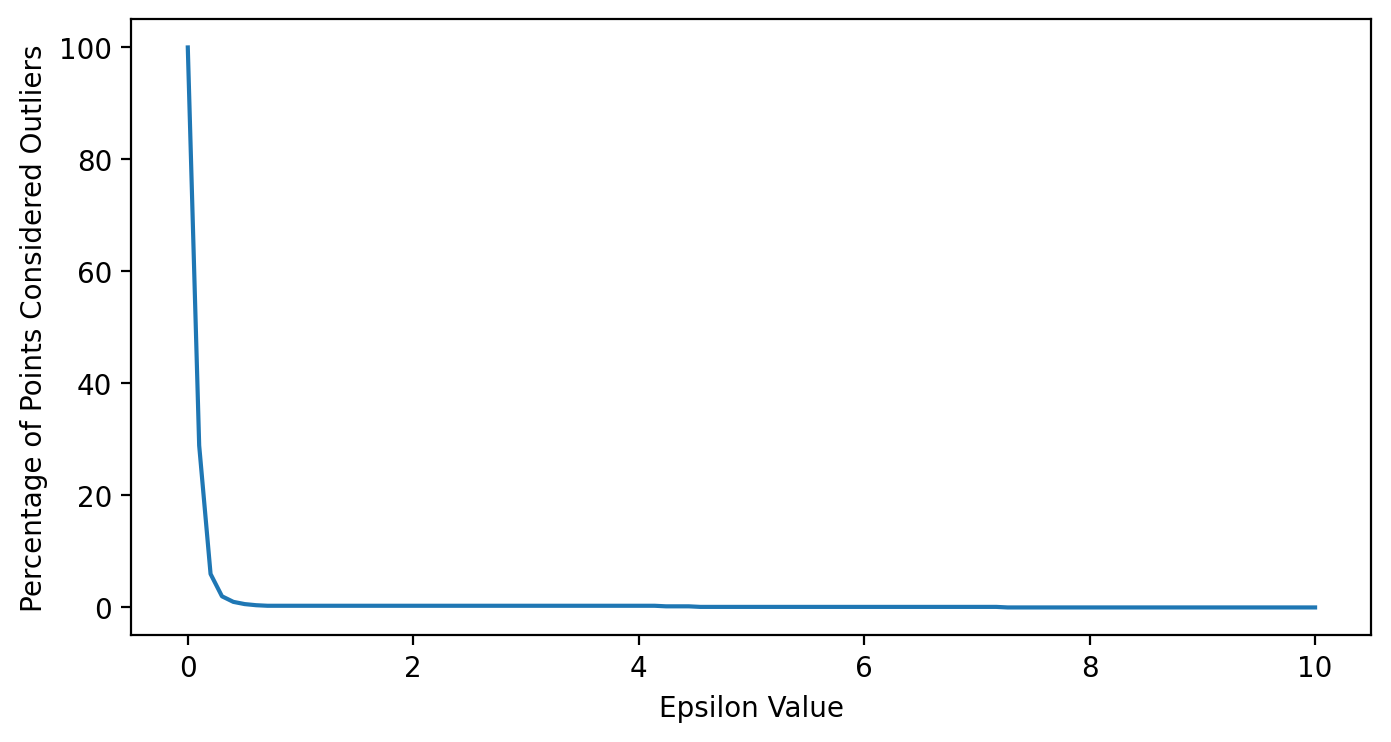

In [35]:
# Plotting Percentage of Outliers:

plt.figure(figsize= (8,4), dpi=200)
plt.plot(np.linspace(0.001, 10, 100), percentage_of_outliers)
plt.xlabel('Epsilon Value')
plt.ylabel('Percentage of Points Considered Outliers')
plt.show()

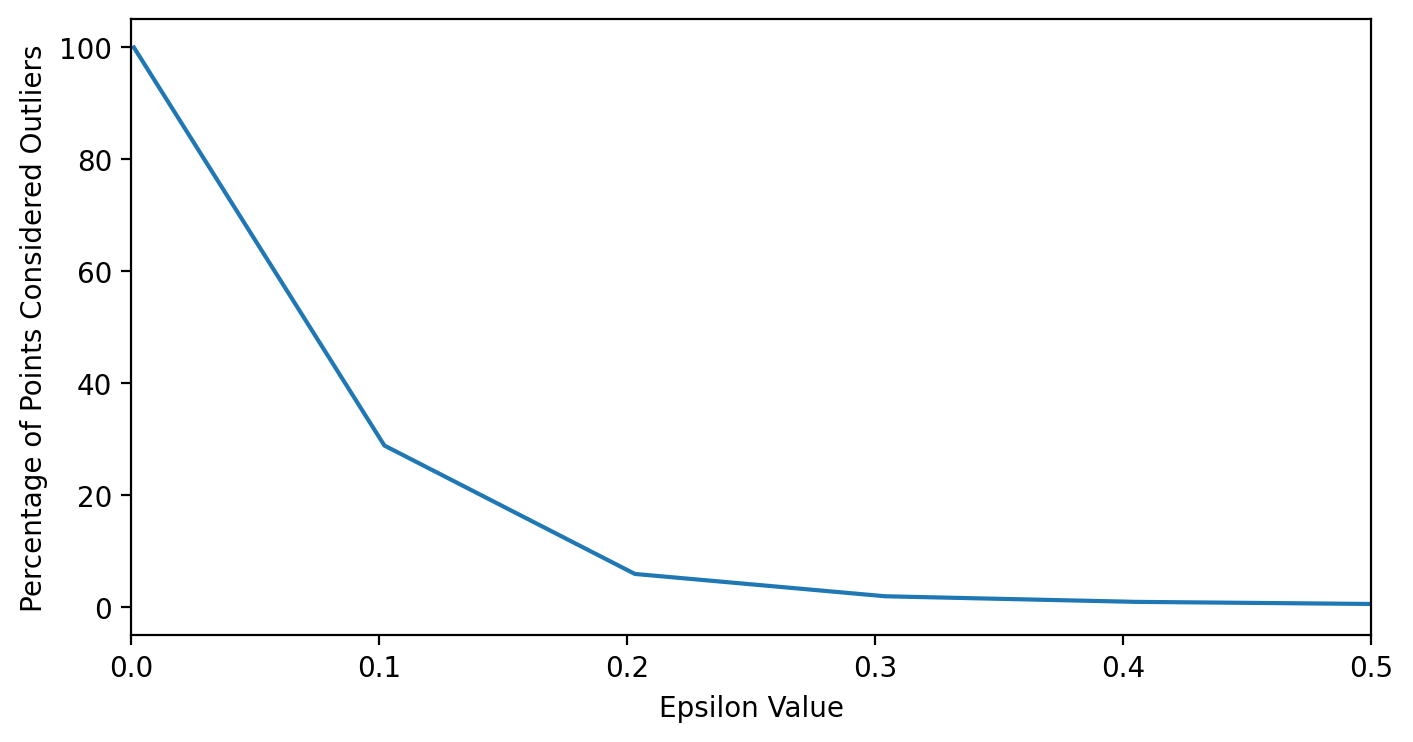

In [36]:
# Plotting Percentage of Outliers:

plt.figure(figsize= (8,4), dpi=200)
plt.plot(np.linspace(0.001, 10, 100), percentage_of_outliers)
plt.xlabel('Epsilon Value')
plt.ylabel('Percentage of Points Considered Outliers')
plt.xlim(0, 0.5)
plt.show()

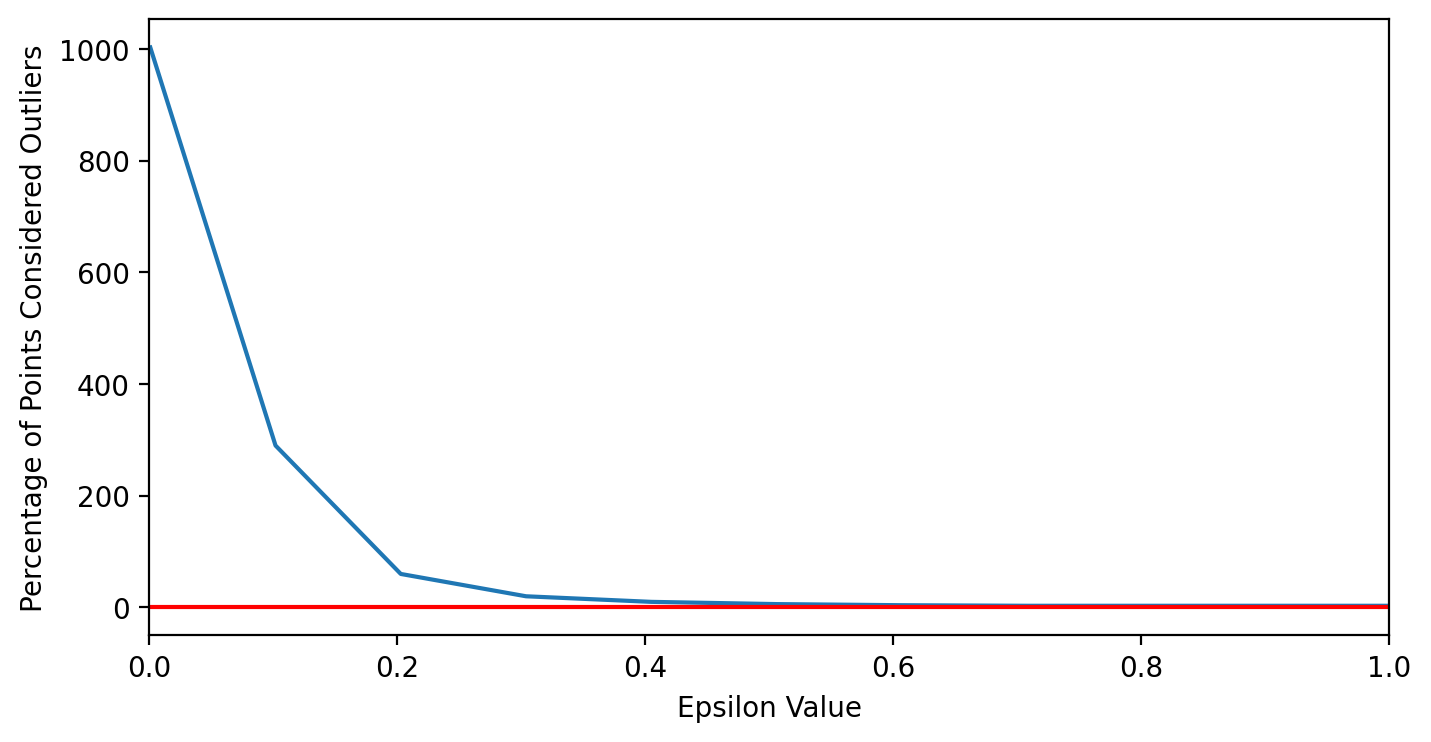

In [37]:
# We can Draw Line on Y-Axis for Y=0.3, to see exactly which value of epsilon is proper.

plt.figure(figsize= (8,4), dpi=200)
plt.plot(np.linspace(0.001, 10, 100), num_of_outliers)
plt.xlabel('Epsilon Value')
plt.ylabel('Percentage of Points Considered Outliers')
plt.xlim(0,1)
plt.hlines(y=0.3, xmin=0, xmax=1, color= 'red')
plt.show()

Here, 0.7 seems to be proper values of Epsilon.

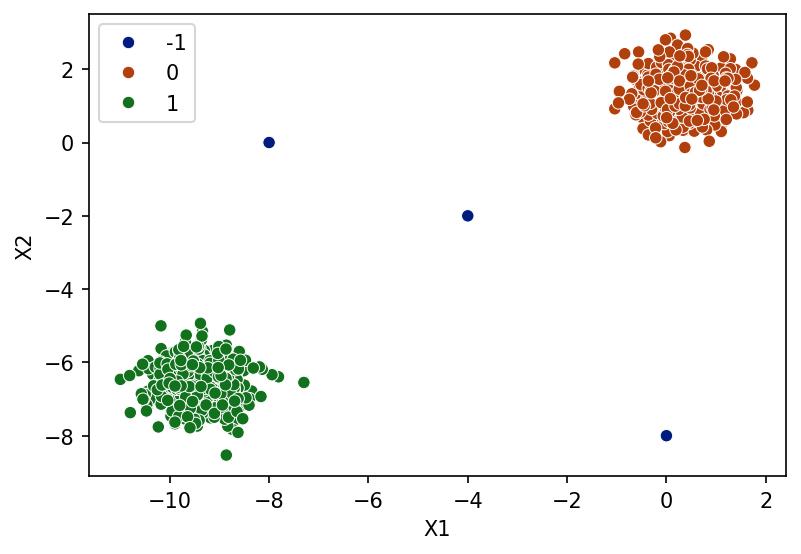

In [38]:
dbscan = DBSCAN(eps= 0.7)
visualize_clusters(dbscan, blobs_2)

In [40]:
np.sum(dbscan.labels_ == -1)

np.int64(3)

##### 5) Finding good 'min_samples' value:

###### 1) Tiny min_smaples value = More Clusters:

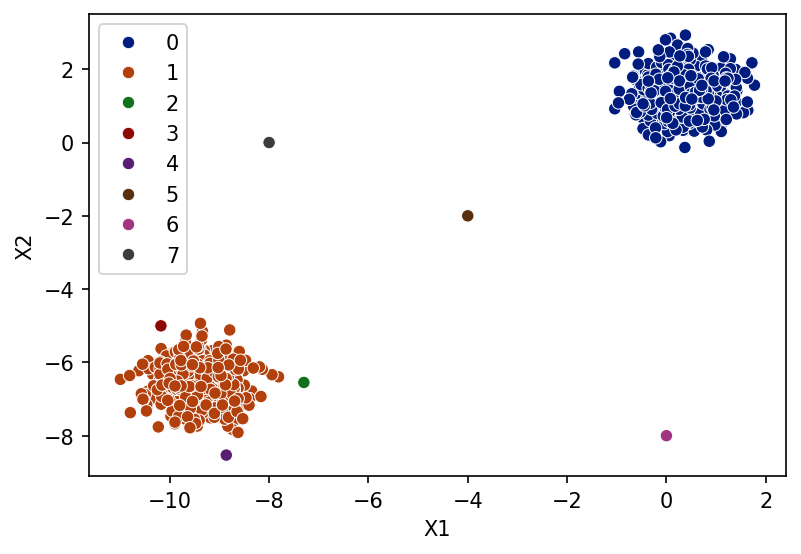

In [42]:
dbscan = DBSCAN(min_samples= 1)
visualize_clusters(dbscan, blobs_2)

###### 2) Huge min_samples value = More Outliers:

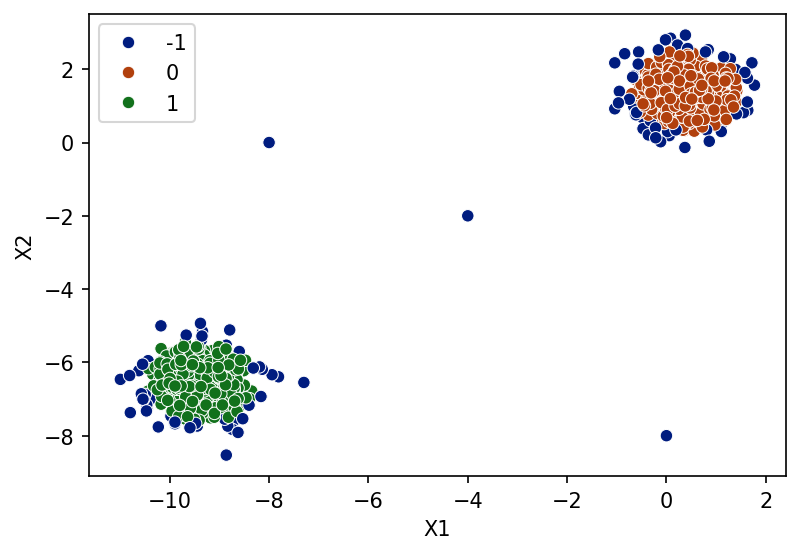

In [43]:
dbscan = DBSCAN(min_samples= 100)
visualize_clusters(dbscan, blobs_2)

###### 3) Finding Proper value for Min_Samples:

- Now, we can run a loop for different "min_samples" values and see how many points OR what Percentage of Points are considered
Outliers for that "min_samples" Value.

- Using that, we can decide proper value of "min_samples".

In [44]:
num_of_outliers = []
percentage_of_outliers = []

for min_samp in range(1,101):
    
    dbscan = DBSCAN(eps= 0.7, min_samples= min_samp)
    
    dbscan.fit(blobs_2)
    
    # Number of Outlier points
    num_of_outliers.append(np.sum(dbscan.labels_ == -1))
    
    # percentage of Outlier Points
    percentage_of_outliers.append(np.sum(dbscan.labels_ == -1) / len(dbscan.labels_) * 100)

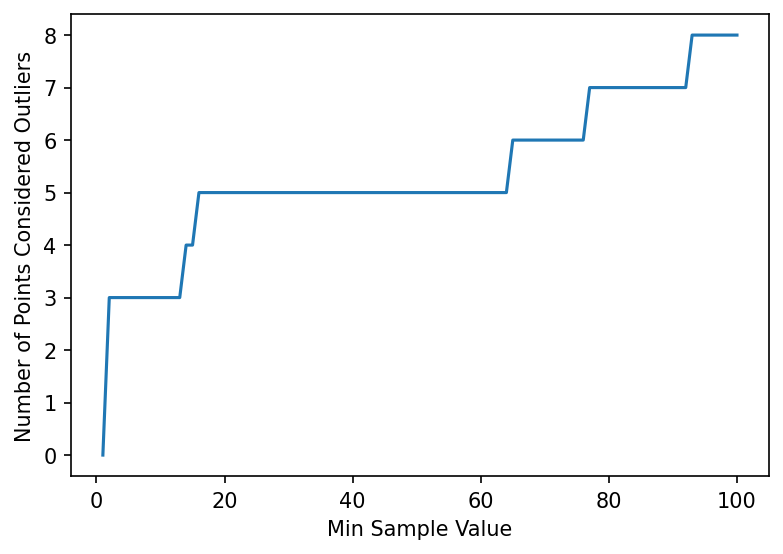

In [47]:
# Plotting Number of Outliers:

plt.figure(figsize= (6,4), dpi= 150)
plt.plot(range(1,101), num_of_outliers)
plt.xlabel('Min Sample Value')
plt.ylabel('Number of Points Considered Outliers')
plt.show()

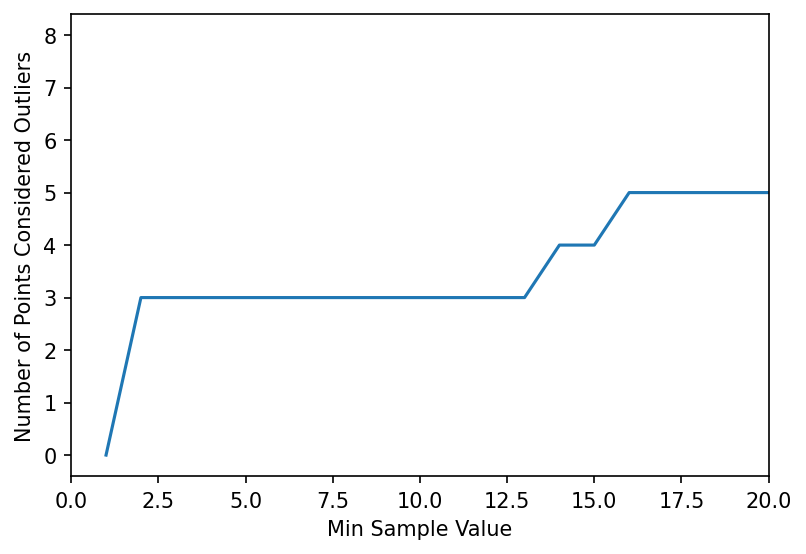

In [48]:
plt.figure(figsize= (6,4), dpi= 150)
plt.plot(range(1,101), num_of_outliers)
plt.xlabel('Min Sample Value')
plt.ylabel('Number of Points Considered Outliers')
plt.xlim(0,20)
plt.show()

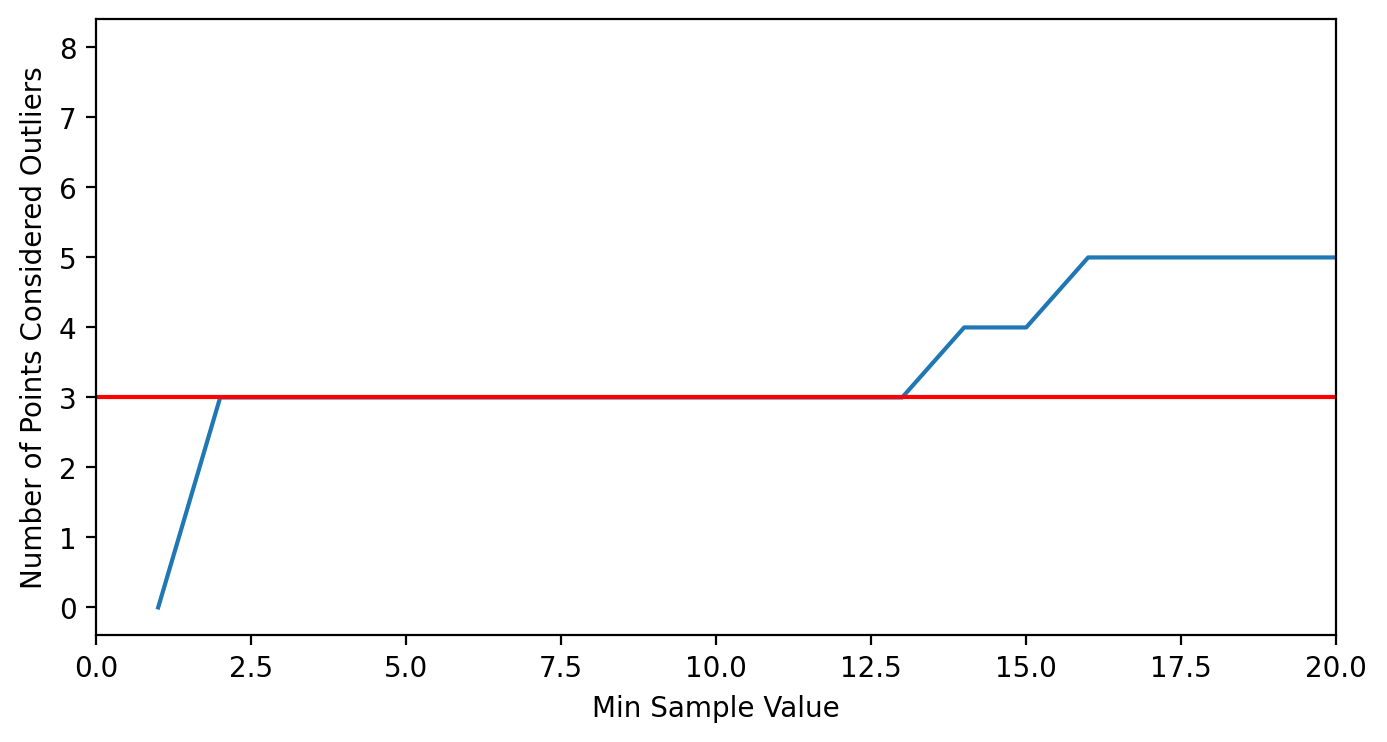

In [49]:
plt.figure(figsize= (8,4), dpi=200)
plt.plot(range(1,101), num_of_outliers)
plt.xlabel('Min Sample Value')
plt.ylabel('Number of Points Considered Outliers')
plt.xlim(0,20)
plt.hlines(y= 3, xmin= 0, xmax= 20, color= 'red')
plt.show()

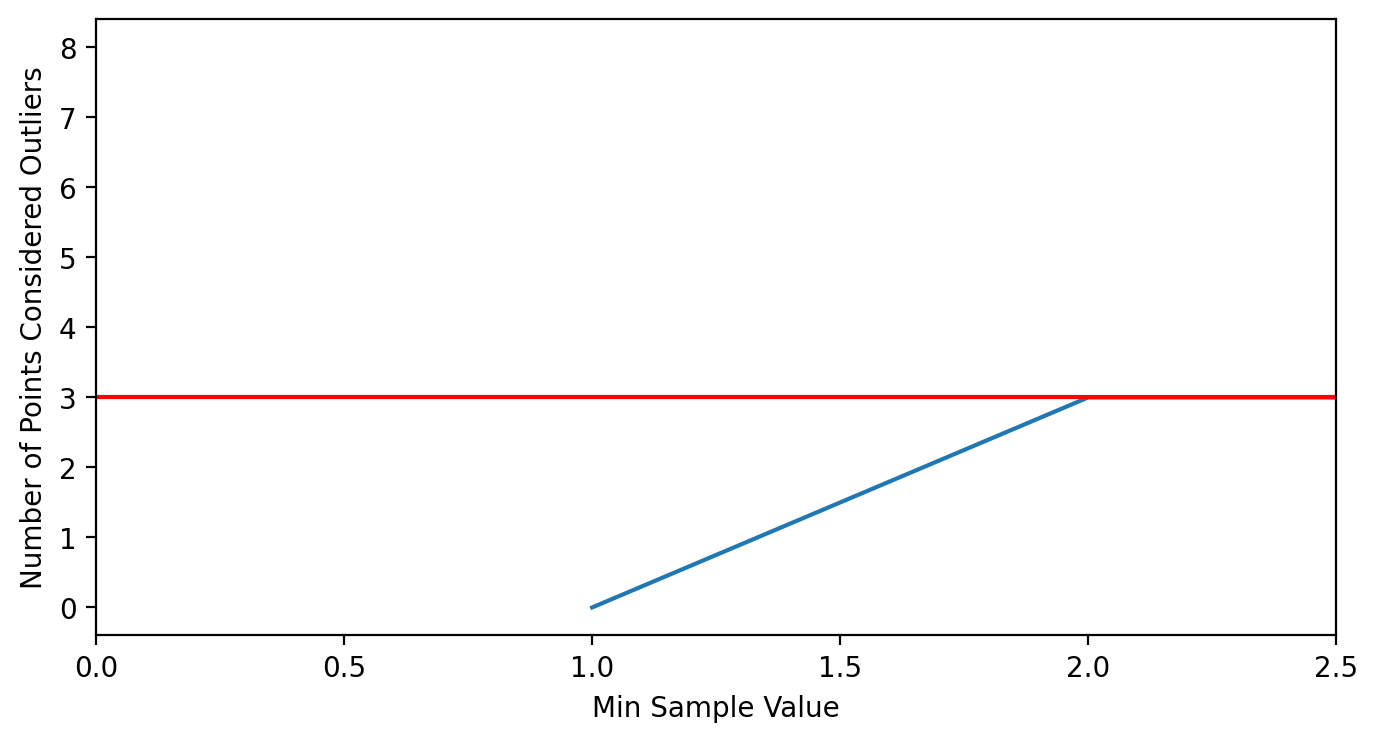

In [50]:
plt.figure(figsize= (8,4), dpi=200)
plt.plot(range(1,101), num_of_outliers)
plt.xlabel('Min Sample Value')
plt.ylabel('Number of Points Considered Outliers')
plt.xlim(0,2.5)
plt.hlines(y= 3, xmin= 0, xmax= 20, color= 'red')
plt.show()

2 Seems to be proper value for 'min_samples'.

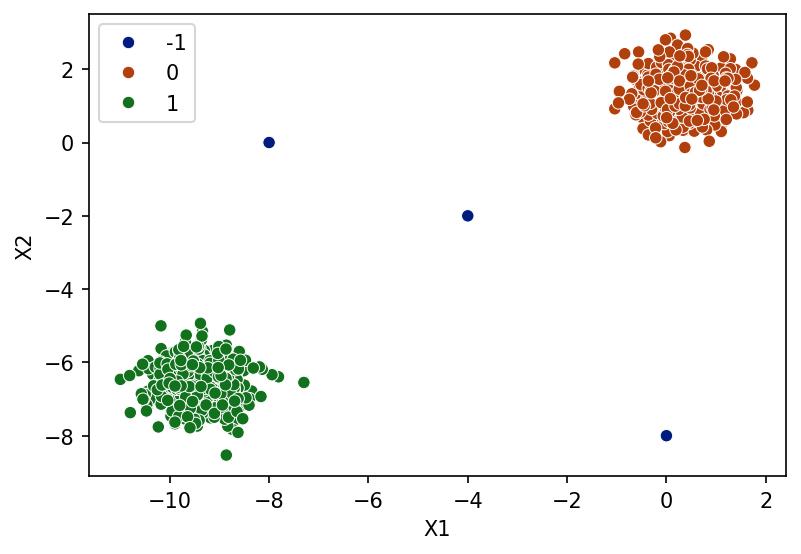

In [51]:
dbscan = DBSCAN(eps= 0.7, min_samples= 2)
visualize_clusters(dbscan, blobs_2)